In the notebook we will investigate *Fourier Series* and use them to fit sinusoids to data 


 # Contents 
 0. Introductory Videos
 1. Fourier Series 
 2. Symbolic Math using `sympy`
 3. Fitting Fourier Series to Data 


# Import statements 

In [137]:
import numpy as  np 
import sympy
sympy.init_printing()
%matplotlib inline

# 0. Intro. Video 

An excellent video describing Fourier Series is linked below:
 -  [https://www.youtube.com/watch?v=r6sGWTCMz2k](https://www.youtube.com/watch?v=r6sGWTCMz2k)

# 1. Fourier Series 


A Fourier series is an expansion of a *periodic* function into a sum of trigonometric functions.

The Fourier series of a function $f(x)$ that is periodic over the interval $[-L,L]$ is given by:

\begin{eqnarray}
f(x)= \frac{a_0}{2} + \sum\limits_{n=1}^\infty a_n \cos(\frac{n \pi x}{L}) + \sum\limits_{n=1}^\infty b_n \sin(\frac{n \pi x}{L})
\end{eqnarray}   


where 

\begin{eqnarray}
a_0 &=& \frac{1}{L} \int_{-L}^{L} f(x)dx \\ 
a_n &=& \frac{1}{L} \int_{-L}^{L} f(x) \cos(\frac{n \pi x}{L})dx \\ 
b_n &=& \frac{1}{L} \int_{-L}^{L} f(x) \sin(\frac{n \pi x}{L})dx \\ 
\end{eqnarray}   

and $\{n\} = 1,2,...,\infty$

A different way to say this is that we can represent any *periodic* function using a set of sine and/or cosine functions. 


For more background information on Fourier Series, see 
 - https://mathworld.wolfram.com/FourierSeries.html
 - https://en.wikipedia.org/wiki/Fourier_series
 - https://dynamics-and-control.readthedocs.io/en/latest/1_Dynamics/8_Frequency_domain/Fourier%20series.html
 - https://klyshko.github.io/teaching/2019-02-22-teaching
 - https://computationalmindset.com/en/mathematics/fourier-series-in-python.html
 - https://docs.sympy.org/latest/tutorials/intro-tutorial/basic_operations.html#evalf
 

# 2. Symbolic Math using `sympy`

In `fundamentals_16.ipynb` we briefly looked at `sympy`, a Python library for symbolic mathematics.

In particular, we looked at how to use `sympy` to calculate both *definite* and *indefinite* integrals. 

In the cells below, we review that process.



### Integration in `sympy` 
1. You have to declare your variable using `Symbol`
2. You can perform indefinite & definite integrals

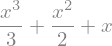

In [138]:
x = sympy.Symbol('x')
sympy.integrate(x**2 + x + 1, x)       ## <<-- Indefinite integral (no limits supplied)

In [139]:
sympy.integrate(x**2 + x + 1, (x,0,1)) ## <<-- Definite integral (limits supplied)

### Integrating a function 

You can supply a function and `sympy` will integrate it ...

N.B. In the integral below, $\int f(x) dx \equiv \int x dx = \frac{x^2}{2}$

In [140]:
# Define a simple linear function, f(x) = x
def f(x):
    return x 

# Indefinite integral of the function w.r.t. `x`
x = sympy.Symbol('x')
sympy.integrate( f(x), x)


In [141]:
# Definite integral of the function w.r.t. `x` in the interval  -1:1 
interval = (x, -1,1)
sympy.integrate( f(x), interval)

### Integrate the above expressions for the Fourier Series Coefficients 

In [142]:
# Expression for a0
interval = (x, -1,1)
a0 = sympy.integrate( f(x), interval) / 1.

# Expressions for an & bn that are functions of `n`
def a(n, L=1.):
    interval = (x, -L,L)
    return sympy.integrate( f(x) * sympy.cos(n*np.pi*x/L) , interval) / L
def b(n, L=1.):
    interval = (x, -L,L)
    return sympy.integrate( f(x) * sympy.sin(n*np.pi*x/L) , interval) / L


For $f(x)=x$, when we calculate the integral for $a_n = \frac{1}{L} \int_{-L}^{L} f(x) \cos(\frac{n \pi x}{L})dx$, we find that the values for $a_n$ are always zero.

In [143]:
print('a0=', a0)

for n in range(5):
    print(f'a(n={n})=', a(n))
    

for n in range(5):
    print(f'b(n={n})=', b(n))

a0= 0
a(n=0)= 0
a(n=1)= 0
a(n=2)= 0
a(n=3)= 0
a(n=4)= 0
b(n=0)= 0
b(n=1)= 0.636619772367581
b(n=2)= -0.318309886183791
b(n=3)= 0.212206590789194
b(n=4)= -0.159154943091895


### Use `sympy` to sum the Fourier Series expression
\begin{eqnarray}
f(x)= \frac{a_0}{2} + \sum\limits_{n=1}^\infty a_n \cos(\frac{n\pi x}{L}) + \sum\limits_{n=1}^\infty b_n \sin(\frac{n\pi x}{L})
\end{eqnarray} 

In [144]:
# A function that returns the fourier series for a given a0, a(n) & b(n)
# N.B. This is returning the entire series, with all components from n=1 ...to... n=N 
def FS(N, a0, an, bn, L=1.0 ):
    
    result = a0/2
    
    for n in range(1, N) : 
        result += an(n)*sympy.cos(n*np.pi*x/L) + bn(n)*sympy.sin(n*np.pi*x/L)

    return result 


# Calculate the fourier series up to N=5
# NB(1): a0, a & b are the expressions defined above, and they use f(x) = x 
FS(2, a0, a, b)

N.B. There are no `cosine` components in the above, only `sine` components. 


### Use `sympy` to make plots
`sympy` has some nice functionality that allows us to pass in a plotting `interval` as a convenience when plotting functions...

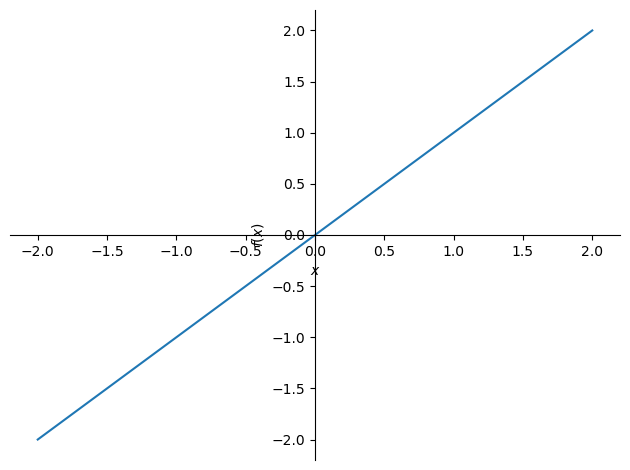

In [145]:
interval = (x, -2,2)
p1 = sympy.plot(f(x), interval, show=True)

In [146]:
FS(2, a0, a, b)

Now we plot the results of evaluating `FS(N)` for various values of `N`.

Note that in the plot below 
 1. When `n` is small, the wavelength is *long* 
 2. As we go to higher `n`, the wavelengths get *shorter* (*higher frequency) 
 3. The fouries series assumes the function is periodic, and hence is only a good approximation in the range of integration (which was -1 to +1 in this example)

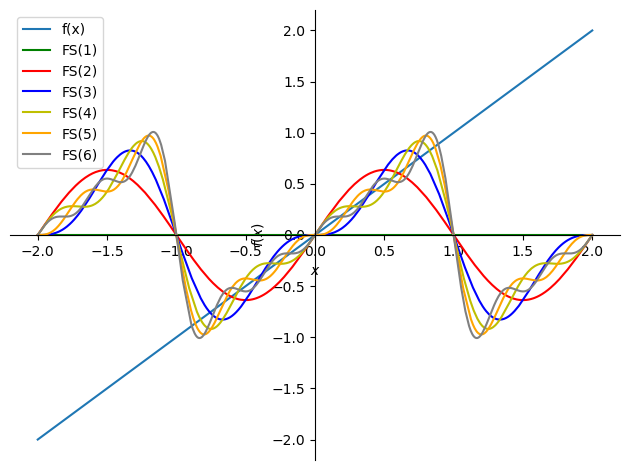

In [149]:
p1 = sympy.plot(f(x), interval, show=False, legend = True ) ; p1[0].label = 'f(x)'
colors = ['k','g','r','b','y','orange','gray']
for n in range(1,7):
    p2 = sympy.plot(FS(n,a0, a, b), interval, line_color=colors[n], show=False, legend = True) ; p2[0].label = f'FS({n})'
    p1.extend(p2)
#p1.legend()
p1.show()

# Exercise (A)
 1. Create a function `get_fourier(f, N, L)` that brings together the steps above to ...
  - evaluate the coefficients for a given function, `f`, ...
  - over the interval `[-L,L]` ...
  - and returns the expression for the Fourier Series to order `N`
 2. Test that your function can reproduce the results above for $f = x$
 3. Use your to evaluate the fourier series for the function $f(x) = x^2$
 4. Plot a comparison of $f(x) = x^2$ and `get_fourier(f,1)`,`get_fourier(f,2)`,...`get_fourier(f,11)`
 5. Compare the results for $L=2$ and $L=3$
 

# 3. Fitting Fourier Series to Data 

In the above, we needed to know the function, `f(x)` in order to calculate the coefficients. 

In practice, we want to express some data/signal in terms of a set of sin & cos functions. 

I.e. we don't need to know a function form for `f(x)`, and instead we just *fit* a set of sin & cos functions to the data. 

To show how to do this, we move away from the symbolic `sympy` approach from above, and instead use an approach based around the `scipy.optimize.curve_fit` we used in data_analyis_5.py 


In [42]:
import numpy as np 
import matplotlib.pyplot as plt

### Numerical version of fourier series expansion

Recall
\begin{eqnarray}
f(x)= \frac{a_0}{2} + \sum\limits_{n=1}^\infty a_n \cos(\frac{n\pi x}{L}) + \sum\limits_{n=1}^\infty b_n \sin(\frac{n\pi x}{L})
\end{eqnarray}   

Let's define a standard python function that will allow us evaluate this expression up to N-terms ...


In [43]:
def fourier(x_arr, *c):
    """
    x_arr: array
     - x-values to be evaluated
     
    c: list of coefficients to be used within the fourier series evaluation
     - c[0] == L
     - c[1] == a_0
     - c[2:int((len(coeff)+2)/2)] == a_n
     - c[int((len(coeff)+2)/2):]  == b_n
    """
    coeffs = c[0] if len(c) == 1 else c
    nC    =len(coeffs)
    assert nC % 2 == 0, f'nC={nC} , %2={nC % 2}' # This is checking that the number of coefficients is *even* 
    assert nC >= 4
    L  = coeffs[0] 
    a0 = coeffs[1]
    a_ = coeffs[2:int((nC+2)/2)]
    b_ = coeffs[int((nC+2)/2):]
    
     
    # We create an array, the same size as the x-array, with each value = a0/2 
    ret = np.array( [a0/2]*len(x_arr)  )

    # Now we loop over N and add each component to the series
    for n in range(len(a_)) :
        ret += a_[n]*np.cos( x_arr*(n+1) * np.pi/L ) + b_[n]*np.sin( x_arr*(n+1)*np.pi/L ) 
    return ret 




Let's check that the above function gives us the same results that we saw when using `sympy` ... 

We do this by comparing the points from `get_fourier` (made using `sympy`) with the new `fourier` function we just created above 

In [44]:
# Create a lambda-ified version of the fourier series/function
# - This allows you to evaluate lots of values 
# - See https://docs.sympy.org/latest/tutorials/intro-tutorial/basic_operations.html#evalf
def f(x): return x**2
x = sympy.Symbol('x')
f5 = sympy.lambdify(x, get_fourier(f, 5) , "numpy") 

f5( np.array( [0., np.pi] ) )

array([0.00966844, 0.76827758])

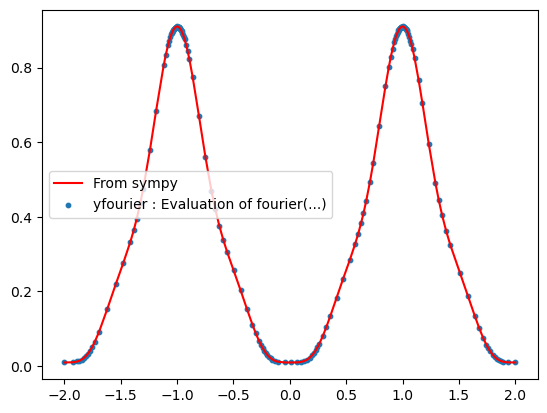

In [45]:
# Plot a figure comparing the values from `get_fourier` (made using `sympy`) with ...
# ... the new `fourier` function we just created above ...
fig = plt.figure()
ax1 = fig.add_subplot(111)

# Values from the sympy approach ( a few cells above)
def f(x): return x**2
n = 5 
xSym,ySym = sympy.plot(get_fourier(f, n), interval, show=False, legend = True)[0].get_points()
plt.plot(xSym,ySym, c='r', label='From sympy')

# Values from our new `fourier` function
# NB: We have to give it coefficient-values ...
#  -> For the sake of this comparison, we just use the coefficents from the sympy approach
coeffs = np.array([ 1.0 , 
                    2/3, 
                    -0.405284734569351, 0.101321183642338, -0.0450316371743723, 0.0253302959105844,
                    0, 0, 0, 0])
yfourier = fourier(np.array(xSym), coeffs)
plt.scatter(xSym,yfourier, s=10, label='yfourier : Evaluation of fourier(...)')

plt.legend()
plt.show()

### Fitting the data using curve_fit

Now we can use our `fourier` function from above to fit some data by passing it into the `curve_fit` routine we used in data_analysis6.ipynb.

N.B. When we use our new `fourier` function like this, *we are not evaluating any integrals in order to get $a_n$ & $b_n$*. Instead we are just passing in numerical values for them and varying them until we get a good fit to data. 

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


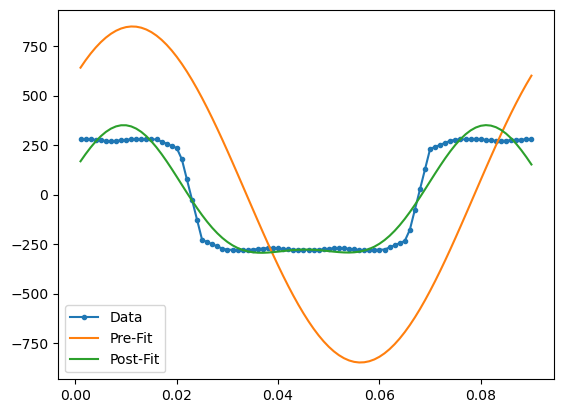

In [46]:
# Import some data from file ... 
xdata,ydata = np.loadtxt('data.txt',delimiter=',', unpack=True)
p1, = plt.plot(xdata, ydata,'.-', label='Data')

# Illustrate what the fit looks like for some initial guess at the coefficients ...
L = 0.045
a0 = 2/3
a1 = 600
b1 = 600 
init_coeff_guess = np.array([ L , a0, a1, 0.0, b1, 0.0]) 
plt.plot(xdata, fourier(xdata, init_coeff_guess), label='Pre-Fit')

# Fit the data using curve_fit 
from scipy.optimize import curve_fit
popt, pcov = curve_fit(fourier, xdata,ydata,init_coeff_guess) 

# Plot the best-fit line 
p,= plt.plot(xdata, fourier(xdata, *popt), label=f'Post-Fit')

plt.legend() 
plt.show() 

### Varying the number of components we provide 
 - As we increase the number of components, the fitted line gets closer and closer to the data 

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


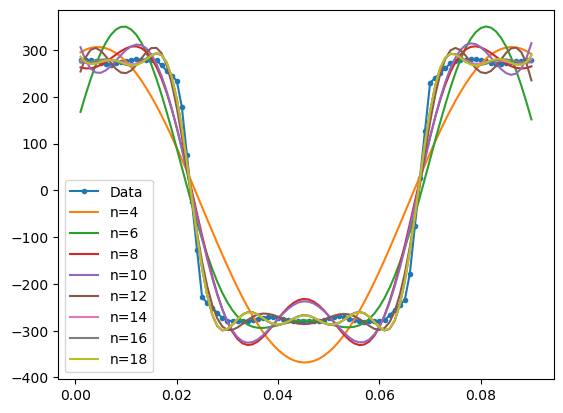

In [47]:
from scipy.optimize import curve_fit
p1, = plt.plot(xdata, ydata,'.-', label='Data')

for n in range(4,20,2):
    init_coeff_guess = np.array( [ L , a0, a1 ] + [1.0]*(n-3) )

    # Fit the data using curve_fit 
    popt, pcov = curve_fit(fourier, xdata,ydata,init_coeff_guess) 
    # Plot the best-fit line 
    p,= plt.plot(xdata, fourier(xdata, *popt), label=f'n={n}')

plt.legend() 


# Exercise (B)
 1. Import the data from the `triangle.txt` into `x_triangle` & `y_triangle` arrays 
 2. Use the `curve_fit` & `fourier` functions to fit the `x_triangle` & `y_triangle` data
  - What happens if: `init_coeff_guess = np.array([ 1., 1., -1., -1., -1., -1. ])` 
  - What happens if: `init_coeff_guess = np.array([ 1000., 10., -1., -1., -11., -11.])`
